# 特徵工程 (Feature Engineering)

學習目標：
- 了解為什麼要做特徵縮放
- 學會三種縮放方法：MinMax、Standard、Robust
- 知道什麼情況用哪種

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

## 1. 為什麼要縮放？

假設預測運動員成績，特徵有：
- 年齡：18~30
- 體重：50~100 kg
- 訓練時數：0~500 小時

體重和訓練時數的數字差很多，
沒有縮放的話，模型會以為「訓練時數」比較重要，
但其實只是數字比較大而已！

In [2]:
# 建立模擬運動員資料（有一個離群值）
data = np.array([[18, 55, 120],
                 [22, 70, 200],
                 [25, 80, 350],
                 [19, 60, 150],
                 [30, 95, 480],
                 [23, 200, 100]])  # 體重200是離群值

print('原始資料：')
print('年齡  體重  訓練時數')
print(data)

原始資料：
年齡  體重  訓練時數
[[ 18  55 120]
 [ 22  70 200]
 [ 25  80 350]
 [ 19  60 150]
 [ 30  95 480]
 [ 23 200 100]]


## 2. MinMax 縮放

把所有數值壓縮到 0~1 之間。
公式：(x - min) / (max - min)

優點：直觀，範圍固定
缺點：對離群值敏感

In [3]:
minmax = MinMaxScaler()
data_minmax = minmax.fit_transform(data)

print('MinMax 縮放後：')
print(np.round(data_minmax, 3))
print('\n注意：體重那欄，200kg的那筆變成1.0，其他都被壓縮了')

MinMax 縮放後：
[[0.    0.    0.053]
 [0.333 0.103 0.263]
 [0.583 0.172 0.658]
 [0.083 0.034 0.132]
 [1.    0.276 1.   ]
 [0.417 1.    0.   ]]

注意：體重那欄，200kg的那筆變成1.0，其他都被壓縮了


## 3. Standard 縮放（Z-score）

把資料轉換成均值=0、標準差=1。
公式：(x - mean) / std

優點：適合常態分布的資料
缺點：仍受離群值影響

In [4]:
standard = StandardScaler()
data_standard = standard.fit_transform(data)

print('Standard 縮放後：')
print(np.round(data_standard, 3))
print(f'\n縮放後均值：{data_standard.mean(axis=0).round(3)}')
print(f'縮放後標準差：{data_standard.std(axis=0).round(3)}')

Standard 縮放後：
[[-1.216 -0.775 -0.825]
 [-0.21  -0.472 -0.243]
 [ 0.545 -0.27   0.85 ]
 [-0.964 -0.674 -0.607]
 [ 1.803  0.034  1.796]
 [ 0.042  2.156 -0.971]]

縮放後均值：[ 0.  0. -0.]
縮放後標準差：[1. 1. 1.]


## 4. Robust 縮放

用中位數和IQR來縮放，對離群值不敏感。
公式：(x - median) / IQR

優點：離群值影響小（最適合有異常值的運動資料）
缺點：縮放後範圍不固定

In [5]:
robust = RobustScaler()
data_robust = robust.fit_transform(data)

print('Robust 縮放後：')
print(np.round(data_robust, 3))
print('\n注意：離群值（體重200）的影響被大幅降低了')

Robust 縮放後：
[[-0.947 -0.696 -0.297]
 [-0.105 -0.174  0.135]
 [ 0.526  0.174  0.946]
 [-0.737 -0.522 -0.135]
 [ 1.579  0.696  1.649]
 [ 0.105  4.348 -0.405]]

注意：離群值（體重200）的影響被大幅降低了


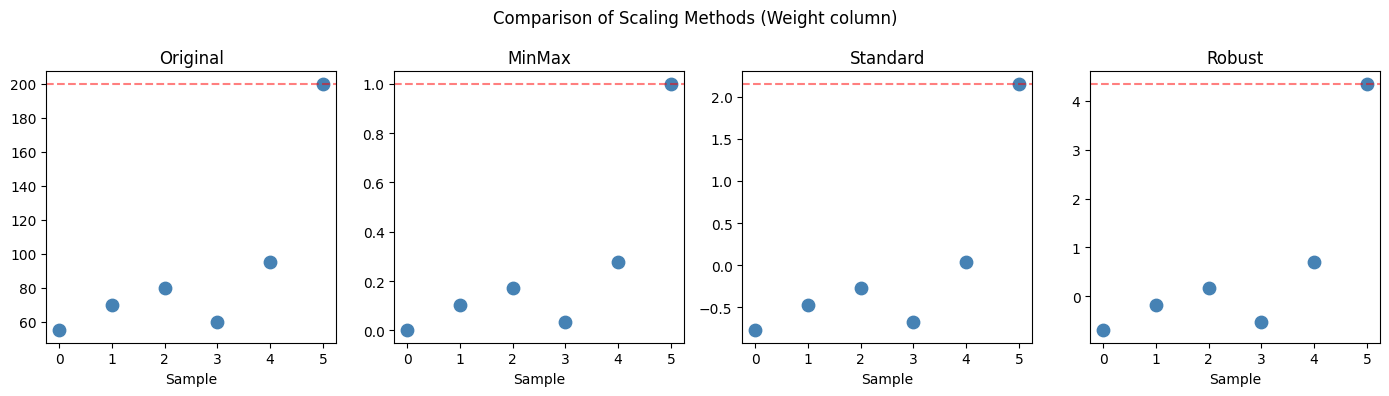

In [6]:
# 視覺化比較三種縮放方法（以體重欄為例）
weight_original = data[:, 1]
weight_minmax = data_minmax[:, 1]
weight_standard = data_standard[:, 1]
weight_robust = data_robust[:, 1]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
datasets = [weight_original, weight_minmax,
            weight_standard, weight_robust]
titles = ['Original', 'MinMax', 'Standard', 'Robust']

for ax, d, t in zip(axes, datasets, titles):
    ax.scatter(range(len(d)), d, color='steelblue', s=80)
    ax.axhline(y=d[-1], color='red', linestyle='--',
               alpha=0.5, label='outlier')
    ax.set_title(t)
    ax.set_xlabel('Sample')

plt.suptitle('Comparison of Scaling Methods (Weight column)')
plt.tight_layout()
plt.show()

## 5. 我的學習筆記

1. 這個主題在做什麼：
   把不同範圍的特徵統一縮放，
   讓模型不會因為數字大小而產生偏差。

2. 三種方法比較：
   - MinMax：資料乾淨、沒有離群值時用
   - Standard：資料接近常態分布時用
   - Robust：資料有離群值時用（運動員資料常見）

3. 我覺得最難理解的地方：
   （填入你自己的想法）

4. 這個跟我研究的連結：
   運動員資料常有異常值（受傷、停賽），
   所以 Robust Scaler 在運動科學研究中特別實用。
   建模前一定要先做特徵縮放。